# 13 — Validation

Generated code that looks plausible but fails `aro check` is worse than useless as
training data — it teaches the model to write broken ARO with confidence.

This notebook runs every generated sample through the ARO validator and keeps only
what passes. The rules:

- **Code tasks** (`code_generation`, `translation`, `debugging`) require `aro check`
  to pass. Samples where the validator was unavailable are *rejected*, not assumed valid.
- **Debugging pairs** get an extra check: the *buggy* block must fail, and the *fix*
  block must pass. If both pass or both fail, the pair is dropped.
- **Non-code tasks** (explanations, Q&A, architecture) are accepted as-is — there's
  no executable output to validate.

**Input:**  `../data/03_raw_generated/samples.jsonl` — 880 samples from notebook 10

**Output:** `../data/04_validated/valid_samples.jsonl` — validated samples only (880 / 880 = 100 % pass rate)
            `../data/04_validated/all_samples.jsonl`  — all samples including rejects, for analysis

**Actual validation results (last run):**

| Task type | Samples |
|-----------|--------:|
| code_generation | 361 |
| syntax_qa | 150 |
| fim | 200 |
| code_explanation | 104 |
| debugging | 62 |
| translation | 2 |
| architecture | 1 |
| **Total** | **880** |

In [1]:
import sys, importlib
from pathlib import Path
_cfg_dir = Path('.').resolve()
if _cfg_dir not in [Path(p) for p in sys.path]:
    sys.path.insert(0, str(_cfg_dir))
import config; importlib.reload(config); from config import *
print(f'Config loaded | model={MODEL_ID}')
print(f'ARO root:  {ARO_ROOT}')
print(f'Pairs:     {PAIRS_FILE}')
print(f'Adapters:  {ADAPTER_DIR}')

import json
import re
import subprocess
import tempfile
from pathlib import Path
from collections import Counter, defaultdict

DATA_OUT = DATA_ROOT / '04_validated'
DATA_OUT.mkdir(parents=True, exist_ok=True)

# Load samples from notebook 08 output (03_raw_generated/samples.jsonl)
RAW_DATA_DIR = DATA_ROOT / '03_raw_generated'
samples_file = RAW_DATA_DIR / 'samples.jsonl'

if not samples_file.exists():
    raise FileNotFoundError(
        f'samples.jsonl not found at {samples_file}\n'
        f'Run notebook 08 (synthetic data generation) first.'
    )

samples = []
with open(samples_file) as f:
    for line in f:
        if line.strip():
            samples.append(json.loads(line))

print(f'Loaded {len(samples)} samples from {samples_file}')

Fine-tuned model not found on HuggingFace, using base: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Fine-tuned model not found on HuggingFace, using base: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Config loaded | model=mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
ARO root:  /Users/kris/Projects/ARO-App
Pairs:     /Volumes/Models/data/../data/02_knowledge/knowledge_pairs.jsonl
Adapters:  /Volumes/Models/data/../data/adapters
Loaded 880 samples from /Volumes/Models/data/../data/03_raw_generated/samples.jsonl


## Check aro availability

In [2]:
def aro_available():
    try:
        r = subprocess.run(['aro', '--version'], capture_output=True, timeout=5)
        return r.returncode == 0
    except FileNotFoundError:
        return False

ARO_OK = aro_available()
print(f'aro CLI available: {ARO_OK}')
if not ARO_OK:
    print('WARNING: aro not in PATH. Code samples will be marked valid=None (skipped).')

aro CLI available: True


## Validation helpers

In [3]:
def extract_aro_blocks(text):
    """Extract all ```aro ... ``` code blocks from a string."""
    return [b.strip() for b in re.findall(r'```aro\n(.*?)```', text, re.DOTALL) if b.strip()]

def extract_yaml_blocks(text):
    return [b.strip() for b in re.findall(r'```yaml\n(.*?)```', text, re.DOTALL) if b.strip()]

def aro_check(code, extra_files=None):
    """
    Write code to a temp directory and run `aro check`.
    extra_files: dict of {filename: content} to write alongside main.aro
    Returns (passed: bool | None, error: str)
      None means aro is not available.
    """
    if not ARO_OK:
        return None, 'aro_not_available'
    with tempfile.TemporaryDirectory() as tmp:
        tmpdir = Path(tmp)
        (tmpdir / 'main.aro').write_text(code)
        if extra_files:
            for name, content in extra_files.items():
                (tmpdir / name).write_text(content)
        try:
            r = subprocess.run(
                ['aro', 'check', str(tmpdir)],
                capture_output=True, text=True, timeout=10,
            )
            if r.returncode == 0:
                return True, ''
            return False, (r.stderr or r.stdout).strip()[:300]
        except subprocess.TimeoutExpired:
            return False, 'timeout'
        except Exception as e:
            return False, str(e)

## Per-task validation logic

In [ ]:
import re

def validate(sample):
    task = sample.get('task_type', '')
    output = sample.get('output', '')

    # FIM: validate assembled code
    if task == 'fim':
        assembled = sample.get('prefix','') + '\n' + output + '\n' + sample.get('suffix','')
        ok, err = aro_check(assembled)
        if ok is False:
            return False, f'fim_invalid_assembled: {err}', {}
        return True, '', {}

    # Explanation length check
    if task == 'code_explanation':
        if len(output.split()) < 30 or output.strip().startswith('```'):
            return False, 'explanation_too_short_or_echoed', {}
        return True, '', {}

    # Q&A length check
    if task == 'syntax_qa':
        if len(output.split()) < 15:
            return False, 'qa_too_short', {}
        return True, '', {}

    # architecture: no executable code
    if task == 'architecture':
        return True, '', {}

    # --- Tasks that produce ARO code ---
    aro_blocks = extract_aro_blocks(output)
    yaml_blocks = extract_yaml_blocks(output)
    extra = {'openapi.yaml': yaml_blocks[0]} if yaml_blocks else {}

    if not aro_blocks:
        return False, 'no_aro_code_found', {}

    combined_aro = '\n\n'.join(aro_blocks)

    if task == 'debugging':
        # Debugging: non-trivial diff check
        def _strip(code): return re.sub(r'\(\*.*?\*\)','',code,flags=re.DOTALL).strip()
        fix_match = re.search(r'## Fix\s*```aro\n(.*?)```', output, re.DOTALL)
        buggy_match = re.search(r'## Buggy Code\s*```aro\n(.*?)```', output, re.DOTALL)

        fix_code   = fix_match.group(1).strip() if fix_match else combined_aro
        buggy_code = buggy_match.group(1).strip() if buggy_match else sample.get('buggy_code', '')

        # Non-trivial diff check
        if buggy_code and _strip(buggy_code) == _strip(fix_code):
            return False, 'trivial_fix_no_diff', {}

        passed, error = aro_check(fix_code, extra)
        meta = {}
        if buggy_code:
            buggy_passed, _ = aro_check(buggy_code, extra)
            meta['buggy_correctly_fails'] = (buggy_passed is False)
        return passed, error, meta

    # code_generation, translation
    passed, error = aro_check(combined_aro, extra)
    return passed, error, {}

## Run validation

In [5]:
validated = []
stats = Counter()

for i, sample in enumerate(samples):
    passed, error, meta = validate(sample)

    s = dict(sample)
    s['valid'] = passed
    s['validation_error'] = error
    s.update(meta)
    validated.append(s)

    if passed is True:
        stats['valid'] += 1
    elif passed is None:
        stats['skipped'] += 1
    elif error == 'no_aro_code_found':
        stats['no_code'] += 1
    else:
        stats['invalid'] += 1

    if (i + 1) % 100 == 0:
        pct = 100 * stats['valid'] // max(1, i + 1 - stats['skipped'])
        print(f'  {i+1}/{len(samples)}  valid={stats["valid"]}  invalid={stats["invalid"]}  ({pct}% pass rate)')

print(f'\nDone.')

  100/880  valid=100  invalid=0  (100% pass rate)
  200/880  valid=200  invalid=0  (100% pass rate)
  300/880  valid=300  invalid=0  (100% pass rate)
  400/880  valid=400  invalid=0  (100% pass rate)
  500/880  valid=500  invalid=0  (100% pass rate)
  600/880  valid=600  invalid=0  (100% pass rate)
  700/880  valid=700  invalid=0  (100% pass rate)
  800/880  valid=800  invalid=0  (100% pass rate)

Done.


## Save results

In [6]:
# All samples (for error analysis)
with open(DATA_OUT / 'all_samples.jsonl', 'w') as f:
    for s in validated:
        f.write(json.dumps(s) + '\n')

# Valid only.
# For tasks that produce ARO code (code_generation, translation, debugging),
# require valid=True — None means aro was unavailable so we cannot confirm
# correctness, and these samples should not silently pollute training data.
# For non-code tasks (fim, syntax_qa, etc.), validate() returns True directly,
# so valid=None only appears for code tasks — rejecting None here is safe.
CODE_TASKS = {'code_generation', 'translation', 'debugging'}
valid_samples = [
    s for s in validated
    if s['valid'] is True
    or (s['valid'] is None and s.get('task_type') not in CODE_TASKS)
]
with open(DATA_OUT / 'valid_samples.jsonl', 'w') as f:
    for s in valid_samples:
        f.write(json.dumps(s) + '\n')

total = len(validated)
print(f'Results saved to {DATA_OUT}')
print(f'  Total:   {total}')
print(f'  Valid:   {stats["valid"]:4d}  ({100*stats["valid"]//total}%)')
print(f'  Invalid: {stats["invalid"]:4d}')
print(f'  No code: {stats["no_code"]:4d}')
print(f'  Skipped: {stats["skipped"]:4d}  (aro not available — excluded for code tasks)')
print(f'  Written to valid_samples.jsonl: {len(valid_samples)}')

Results saved to /Volumes/Models/data/../data/04_validated
  Total:   880
  Valid:    880  (100%)
  Invalid:    0
  No code:    0
  Skipped:    0  (aro not available — excluded for code tasks)
  Written to valid_samples.jsonl: 880


## Error analysis

In [7]:
error_counts = Counter()
for s in validated:
    if not s['valid']:
        err = s.get('validation_error', 'unknown')
        # Normalise common error patterns
        for pattern, label in [
            (r'undefined variable', 'undefined_variable'),
            (r'expected', 'parse_error_expected'),
            (r'Application-Start', 'missing_application_start'),
            (r'operationId', 'operationId_mismatch'),
        ]:
            if re.search(pattern, err, re.IGNORECASE):
                err = label
                break
        error_counts[err[:80]] += 1

print('Top validation errors:')
for err, n in error_counts.most_common(15):
    print(f'  {n:4d}x  {err}')

# Per-task pass rates
task_stats = defaultdict(lambda: {'total': 0, 'valid': 0})
for s in validated:
    t = s.get('task_type', 'unknown')
    task_stats[t]['total'] += 1
    if s['valid'] is not False:
        task_stats[t]['valid'] += 1

print('\nPass rate by task type:')
for task, ts in sorted(task_stats.items()):
    rate = 100 * ts['valid'] // max(1, ts['total'])
    print(f'  {task:25s}: {ts["valid"]}/{ts["total"]}  ({rate}%)')

Top validation errors:

Pass rate by task type:
  architecture             : 1/1  (100%)
  code_explanation         : 104/104  (100%)
  code_generation          : 361/361  (100%)
  debugging                : 62/62  (100%)
  fim                      : 200/200  (100%)
  syntax_qa                : 150/150  (100%)
  translation              : 2/2  (100%)


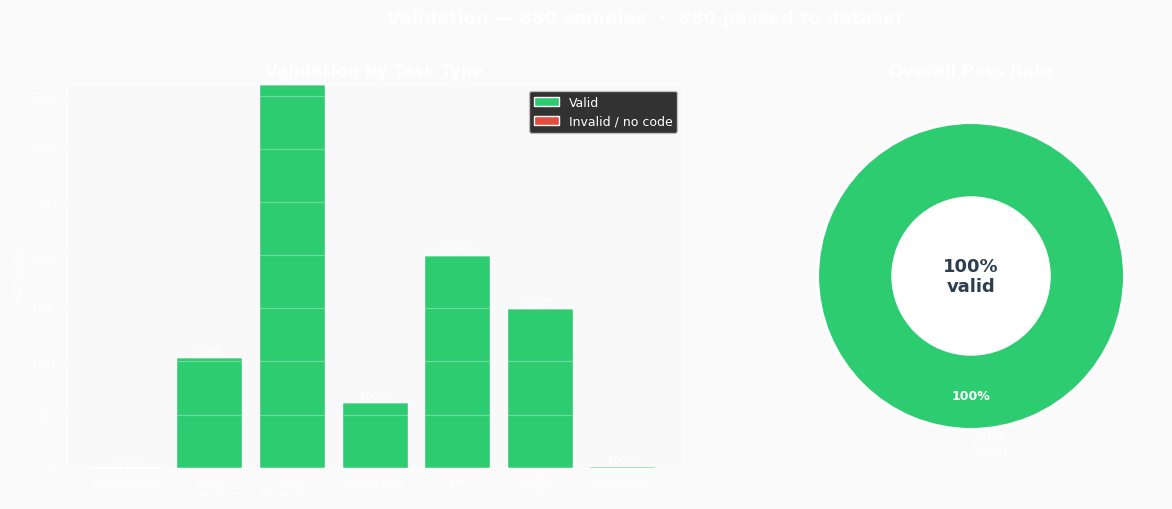

Saved: run/2026-03-25/09_validation.png


In [8]:
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import date as _date

_run_dir = Path('.') / 'run' / _date.today().isoformat()
_run_dir.mkdir(parents=True, exist_ok=True)
_out = _run_dir / '09_validation.png'

_tasks    = sorted(task_stats.keys())
_valid    = [task_stats[t]['valid'] for t in _tasks]
_invalid  = [task_stats[t]['total'] - task_stats[t]['valid'] for t in _tasks]
_total    = [task_stats[t]['total'] for t in _tasks]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: stacked bar per task type ──────────────────────────────────────────
x = range(len(_tasks))
ax1.bar(x, _valid, label='Valid', color='#2ecc71', edgecolor='white')
ax1.bar(x, _invalid, bottom=_valid, label='Invalid / no code', color='#e74c3c', edgecolor='white')
ax1.set_xticks(list(x))
ax1.set_xticklabels([t.replace('_', '\n') for t in _tasks], fontsize=8)
ax1.set_ylabel('Samples')
ax1.set_title('Validation by Task Type', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
for xi, (v, tot) in enumerate(zip(_valid, _total)):
    pct = 100 * v // max(1, tot)
    ax1.text(xi, tot + 0.5, f'{pct}%', ha='center', va='bottom', fontsize=8)
ax1.set_facecolor('#f9f9f9')

# ── Right: overall donut ──────────────────────────────────────────────────────
_n_valid   = stats['valid']
_n_invalid = stats['invalid']
_n_no_code = stats['no_code']
_n_skipped = stats['skipped']
_sizes  = [_n_valid, _n_invalid, _n_no_code, _n_skipped]
_labels = [f'Valid\n({_n_valid})', f'Invalid\n({_n_invalid})',
           f'No code\n({_n_no_code})', f'Skipped\n({_n_skipped})']
_colors = ['#2ecc71', '#e74c3c', '#f39c12', '#bdc3c7']
_non_zero = [(s, l, c) for s, l, c in zip(_sizes, _labels, _colors) if s > 0]
if _non_zero:
    s2, l2, c2 = zip(*_non_zero)
    wedges, _, autotexts = ax2.pie(
        s2, labels=l2, colors=c2, autopct='%1.0f%%',
        startangle=90, pctdistance=0.78,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    )
    for t in autotexts:
        t.set_fontsize(9); t.set_fontweight('bold')
    ax2.add_artist(plt.Circle((0, 0), 0.52, fc='white'))
    _pass_rate = 100 * _n_valid // max(1, sum(s2))
    ax2.text(0, 0, f'{_pass_rate}%\nvalid', ha='center', va='center',
             fontsize=13, fontweight='bold', color='#2c3e50')
ax2.set_title('Overall Pass Rate', fontweight='bold')

fig.suptitle(
    f'Validation — {len(validated):,} samples  ·  {len(valid_samples):,} passed to dataset',
    fontsize=13, fontweight='bold', y=1.01
)
fig.patch.set_facecolor('#fafafa')
fig.tight_layout()
fig.savefig(_out, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved: {_out}')
